# Object Detection – YOLOv5

In [ ]:
# !pip install ultralytics you need to do this 

from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO("yolov5s.pt")  # Small, fast model
results = model("yolotest.jpeg") 
results[0].show()  # Show detection overlay


WARNING ⚠️ torchvision==0.12 is incompatible with torch==2.2.
Run 'pip install torchvision==0.17' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation
PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



# Semantic Segmentation – DeepLabV3 (TorchVision)

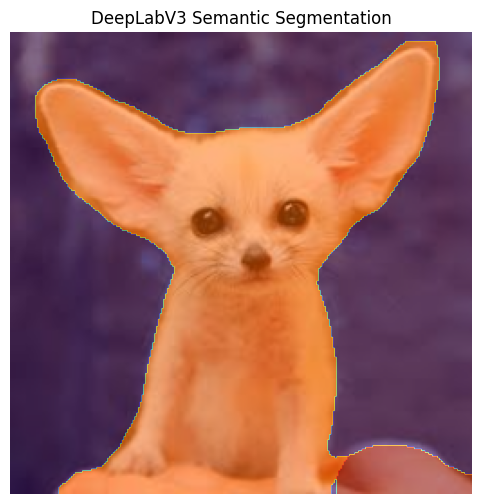

In [16]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load DeepLabV3 pre-trained model
model = models.segmentation.deeplabv3_resnet50(pretrained=True).eval()

# Load and preprocess the image
img_path = "baby.jpeg"  # Replace with your image path
original_img = Image.open(img_path).convert('RGB')
resize_size = (256, 256)

transform = transforms.Compose([
    transforms.Resize(resize_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = transform(original_img).unsqueeze(0)

# Predict segmentation
with torch.no_grad():
    output = model(input_tensor)['out'][0]
segmentation = output.argmax(0).byte().cpu().numpy()

# Convert original image to NumPy for overlay
resized_img = original_img.resize(resize_size)
resized_img_np = np.array(resized_img)

# Plot original + segmentation overlay
plt.figure(figsize=(8, 6))
plt.imshow(resized_img_np)
plt.imshow(segmentation, cmap='jet', alpha=0.5)  # Overlay mask with transparency
plt.title("DeepLabV3 Semantic Segmentation")
plt.axis('off')
plt.show()



In [ ]:
# Image Captioning – BLIP (Hugging Face Transformers)

In [ ]:
# pip install transformers
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

img = Image.open("content.jpg").convert('RGB')
inputs = processor(images=img, return_tensors="pt")
out = model.generate(**inputs)
print("Caption:", processor.decode(out[0], skip_special_tokens=True))
